### The Galaxy Zoo Decision Tree

**Galaxy Zoo** utiliza un árbol de decisiones para guiar a los voluntarios en la clasificación de galaxias.  
El proceso consiste en **11 preguntas** jerárquicas, desde aspectos generales (como si la galaxia es lisa o tiene disco) hasta detalles específicos (como el número de brazos espirales).

Cada pregunta tiene varias posibles respuestas (entre 2 y 7), y cada galaxia recibe múltiples clasificaciones de diferentes usuarios.  
Estas respuestas generan **probabilidades** en cada nodo del árbol.

**Probabilidad condicionada:**  
Cada nueva respuesta depende de las anteriores. Es decir, la probabilidad de una característica más específica (por ejemplo, que una galaxia sea redonda) está **condicionada** a la probabilidad de la categoría previa (por ejemplo, que sea una galaxia lisa).  
Por eso, las probabilidades se multiplican a lo largo del árbol.

**Ejemplo:**  
Si el 80% de los usuarios identifican una galaxia como *smooth*, y dentro de ese grupo el 50% la considera *completamente redonda*, entonces:


$P(\text{smooth \& round}) = P(\text{round} \mid \text{smooth}) \times P(\text{smooth}) = 0.50 \times 0.80 = 0.40$


Este proceso de **multiplicación acumulativa de probabilidades condicionadas** se repite en todo el árbol.  
Así, las clasificaciones superiores siempre suman **1.0**, mientras que las más detalladas pueden sumar **≤ 1.0**.




## Importación de Librerias 

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc, roc_auc_score
)
import cv2


## Carga dataset

In [2]:
df = pd.read_csv("training_solutions_rev1.csv")

## Información del dataset

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61578 entries, 0 to 61577
Data columns (total 38 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   GalaxyID   61578 non-null  int64  
 1   Class1.1   61578 non-null  float64
 2   Class1.2   61578 non-null  float64
 3   Class1.3   61578 non-null  float64
 4   Class2.1   61578 non-null  float64
 5   Class2.2   61578 non-null  float64
 6   Class3.1   61578 non-null  float64
 7   Class3.2   61578 non-null  float64
 8   Class4.1   61578 non-null  float64
 9   Class4.2   61578 non-null  float64
 10  Class5.1   61578 non-null  float64
 11  Class5.2   61578 non-null  float64
 12  Class5.3   61578 non-null  float64
 13  Class5.4   61578 non-null  float64
 14  Class6.1   61578 non-null  float64
 15  Class6.2   61578 non-null  float64
 16  Class7.1   61578 non-null  float64
 17  Class7.2   61578 non-null  float64
 18  Class7.3   61578 non-null  float64
 19  Class8.1   61578 non-null  float64
 20  Class8

In [4]:
print("Primeras filas:")
display(df.head())

Primeras filas:


,GalaxyID,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,Class3.2,Class4.1,Class4.2,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,0.578401,0.418398,0.198455,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,0.165229,0.591328,0.041271,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,0.177352,0.000000,0.177352,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,0.129071,0.189098,0.049466,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


                               Condición  Número de galaxias
0      1. Class1.3 > Class1.1 y Class1.2                  59
1  2. No nulos en 6 y mayor prob. en 6.2               53094
2                      3. No nulos en 11               35306
3                     8.1 mayor (sin 11)                5271
4                     8.2 mayor (sin 11)                6085
5                     8.3 mayor (sin 11)                7816
6                     8.4 mayor (sin 11)                6685
7                     8.5 mayor (sin 11)               14229
8                     8.6 mayor (sin 11)                6322
9                     8.7 mayor (sin 11)                3861


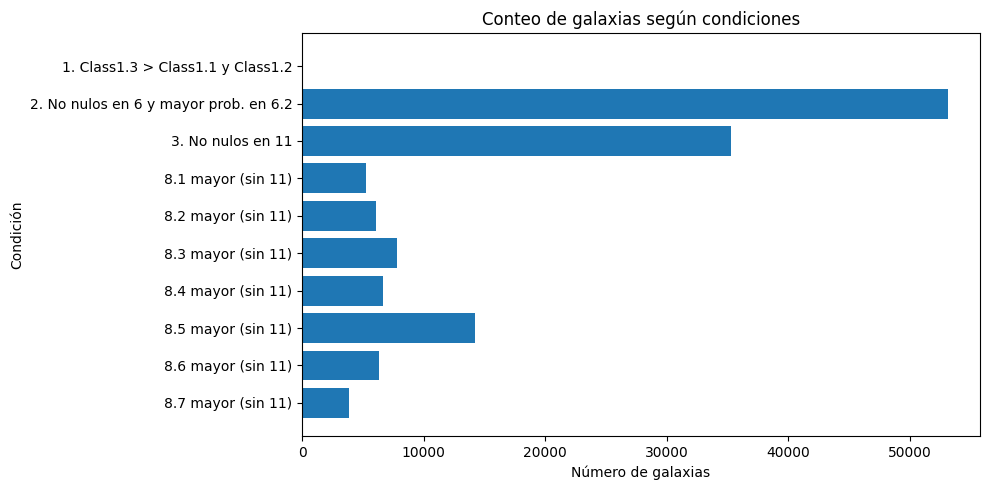

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el CSV
df = pd.read_csv("training_solutions_rev1.csv")

# --- 1. Mayor número en 1.3 que en 1.1 y 1.2
cond1 = (df["Class1.3"] > df["Class1.1"]) & (df["Class1.3"] > df["Class1.2"])

# --- 2. No nulos en 6 y mayor probabilidad en 6.2
cond2 = (df[["Class6.1", "Class6.2"]].sum(axis=1) > 0) & (df["Class6.2"] > df["Class6.1"])

# --- 3. No nulos en 11
cols11 = [f"Class11.{i}" for i in range(1,7)]
cond3 = df[cols11].sum(axis=1) > 0

# --- 4–10. Excluyendo no nulos en 11, mayor probabilidad en cada 8.x
cols8 = [f"Class8.{i}" for i in range(1,8)]
mask_no11 = ~cond3  # excluir los que tienen valores en 11

cond_restantes = {}
for i in range(1, 8):
    cond_restantes[f"8.{i}"] = mask_no11 & (df[f"Class8.{i}"] == df[cols8].max(axis=1))

# --- Contar las galaxias que cumplen cada condición
conteos = {
    "1. Class1.3 > Class1.1 y Class1.2": cond1.sum(),
    "2. No nulos en 6 y mayor prob. en 6.2": cond2.sum(),
    "3. No nulos en 11": cond3.sum(),
}

# Añadir los casos de Class8.x
for k, v in cond_restantes.items():
    conteos[f"8.{k[-1]} mayor (sin 11)"] = v.sum()

# --- Crear tabla resumen
tabla_conteos = pd.DataFrame(list(conteos.items()), columns=["Condición", "Número de galaxias"])
print(tabla_conteos)

# --- Gráfico de barras
plt.figure(figsize=(10,5))
plt.barh(tabla_conteos["Condición"], tabla_conteos["Número de galaxias"])
plt.title("Conteo de galaxias según condiciones")
plt.xlabel("Número de galaxias")
plt.ylabel("Condición")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv("training_solutions_rev1.csv")

# Parámetros
UMBRAL_STAR = 0.5   # opcional: umbral para identificar estrella/artifact sólidamente
UMBRAL_ANOMALY = 0.5

def argmax_in_group(row, cols):
    vals = row[cols].values.astype(float)
    idx = np.nanargmax(vals)
    return cols[idx], vals[idx]

# Ejemplo: detectar tipo principal (Q1)
cols_q1 = ["Class1.1","Class1.2","Class1.3"]
df["main_q1"], df["main_q1_p"] = zip(*df.apply(lambda r: argmax_in_group(r, cols_q1), axis=1))

# Estrella / artefacto
df["is_star"] = (df["main_q1"] == "Class1.3") & (df["main_q1_p"] >= UMBRAL_STAR)

# Detectar si es espiral por prob en Q4 (asumiendo que Class4.1 = yes)
# Ajusta nombres: si el CSV usa otros indices, cámbialos.
df["prob_spiral_yes"] = df.get("Class4.1", 0.0).astype(float)
df["is_spiral"] = df["prob_spiral_yes"] > 0.3  # tú decides el umbral; 0.3 es ejemplo

# Detectar anómala por Q6
df["prob_q6_yes"] = df.get("Class6.2", 0.0).astype(float)
df["is_anomalous"] = df["prob_q6_yes"] > 0.3  # ajustar umbral

# Tipo de anomalía (Q8): argmax entre Class8.1..Class8.7
cols_q8 = [c for c in df.columns if c.startswith("Class8.")]
if cols_q8:
    df["anomaly_type"], df["anomaly_p"] = zip(*df.apply(lambda r: argmax_in_group(r, cols_q8), axis=1))

# Número de brazos (Q11) — si interesa
cols_q11 = [c for c in df.columns if c.startswith("Class11.")]
if cols_q11:
    df["n_arms_choice"], df["n_arms_p"] = zip(*df.apply(lambda r: argmax_in_group(r, cols_q11), axis=1))

# Construir etiqueta final (regla simple y priorizada)
def final_label(r):
    if r["is_star"]:
        return "Star/Artifact"
    if r["is_spiral"]:
        if r["is_anomalous"] and r["anomaly_p"] > 0.2:
            return f"Spiral - {r['anomaly_type']}"
        else:
            return "Spiral - normal"
    # si no es espiral pero features/disk dominante
    if r["main_q1"] == "Class1.2":
        if r["is_anomalous"] and r["anomaly_p"] > 0.2:
            return f"Disk - {r['anomaly_type']}"
        else:
            return "Disk - no spiral"
    # caso smooth
    if r["main_q1"] == "Class1.1":
        # usar Class7.* para redondez
        cols7 = [c for c in df.columns if c.startswith("Class7.")]
        if cols7:
            choice, p = argmax_in_group(r, cols7)
            return f"Smooth - {choice}"
        return "Smooth"
    return "Unknown"

df["final_label"] = df.apply(final_label, axis=1)


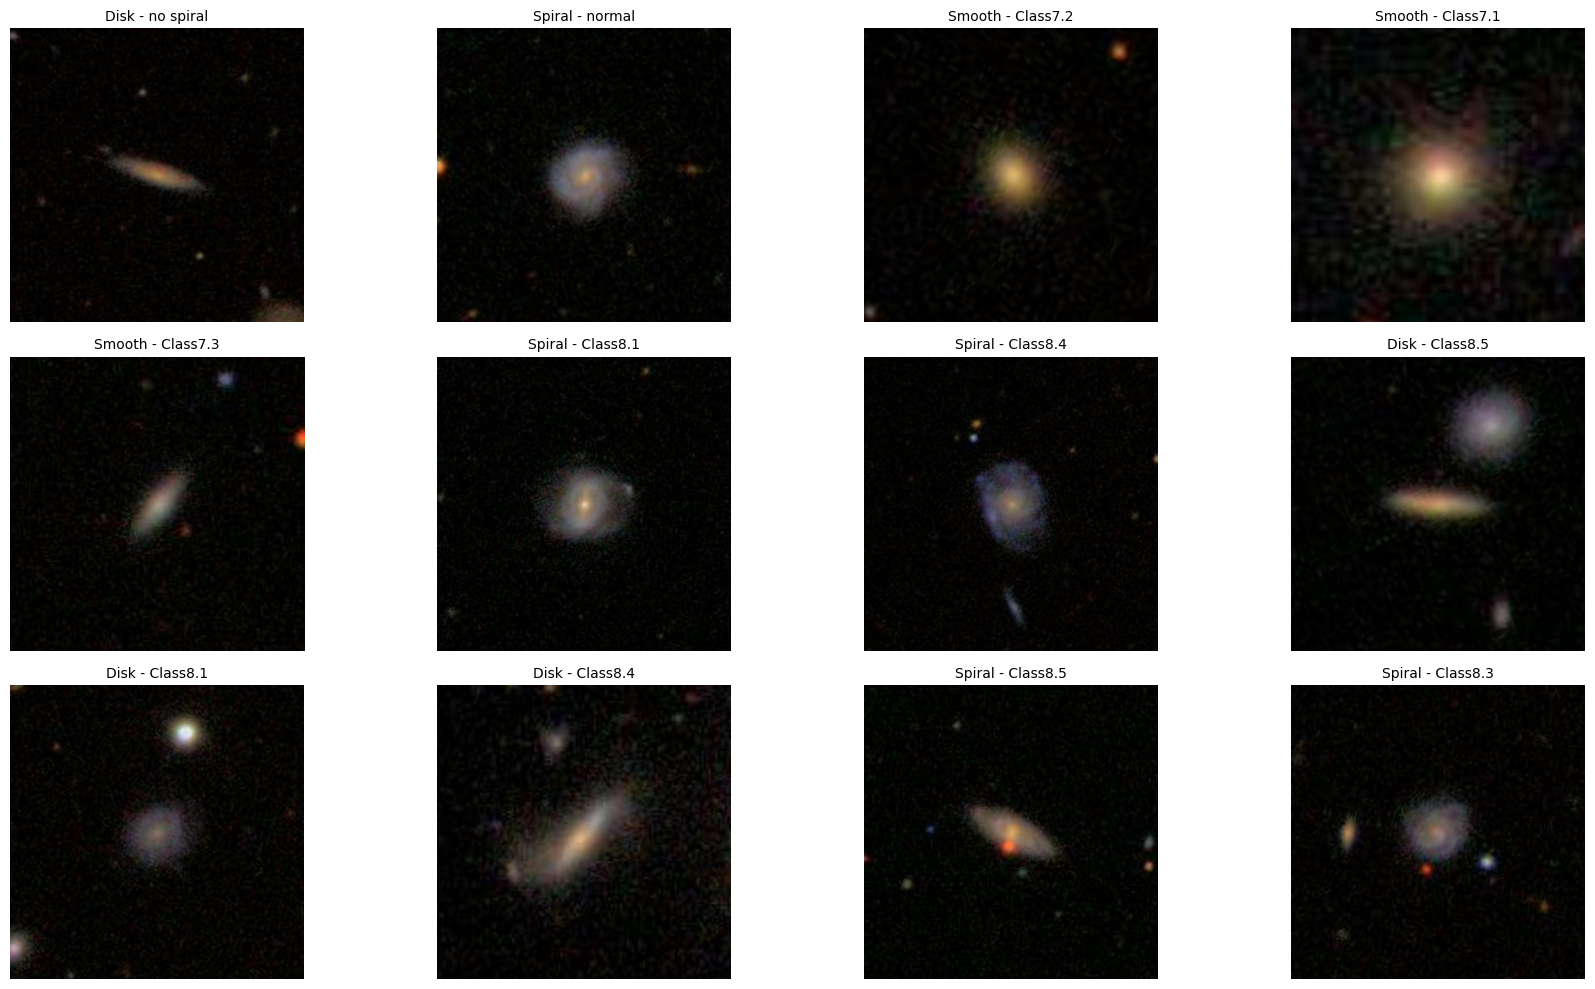

In [7]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Ruta a las imágenes
PATH_IMAGES = "images_training_rev1/"
id_col = "GalaxyID"  # ajusta si tu CSV usa otro nombre

# Verificar que exista la carpeta
if not os.path.exists(PATH_IMAGES):
    raise FileNotFoundError(f"No se encontró la carpeta: {PATH_IMAGES}")

# Obtener las clases únicas en final_label
categorias = df["final_label"].value_counts().head(12).index  # muestra las 12 más frecuentes
#categorias = df["final_label"].unique()


plt.figure(figsize=(18, 10))

for i, cat in enumerate(categorias):
    subset = df[df["final_label"] == cat]
    if subset.empty:
        continue

    # Selecciona una galaxia aleatoria
    sample = subset.sample(1).iloc[0]
    galaxy_id = int(sample[id_col])
    img_path = os.path.join(PATH_IMAGES, f"{galaxy_id}.jpg")

    if not os.path.exists(img_path):
        print(f"No se encontró imagen para {galaxy_id}")
        continue

    # Mostrar imagen
    img = Image.open(img_path)
    plt.subplot(3, 4, i + 1)  # 3 filas x 4 columnas
    plt.imshow(img)
    plt.axis("off")
    plt.title(cat, fontsize=10)

plt.tight_layout()
plt.show()


In [8]:
# Mostrar conteo total de filas
print("Total de galaxias:", len(df))

# Mostrar cantidad por tipo de clasificación
conteo_labels = df["final_label"].value_counts()
print("\nConteo por tipo de clasificación:")
print(conteo_labels)

# Si quieres incluir porcentajes también:
print("\nPorcentajes por tipo:")
print((conteo_labels / len(df) * 100).round(2))


Total de galaxias: 61578

Conteo por tipo de clasificación:
final_label
Disk - no spiral     15513
Spiral - normal      13249
Smooth - Class7.2    12769
Smooth - Class7.1    11845
Smooth - Class7.3     1575
Spiral - Class8.1     1218
Spiral - Class8.4     1016
Disk - Class8.5        913
Disk - Class8.1        912
Disk - Class8.4        681
Spiral - Class8.5      471
Spiral - Class8.3      325
Disk - Class8.6        323
Spiral - Class8.6      315
Disk - Class8.3        214
Disk - Class8.7        153
Star/Artifact           44
Unknown                 15
Spiral - Class8.2       14
Disk - Class8.2         11
Spiral - Class8.7        2
Name: count, dtype: int64

Porcentajes por tipo:
final_label
Disk - no spiral     25.19
Spiral - normal      21.52
Smooth - Class7.2    20.74
Smooth - Class7.1    19.24
Smooth - Class7.3     2.56
Spiral - Class8.1     1.98
Spiral - Class8.4     1.65
Disk - Class8.5       1.48
Disk - Class8.1       1.48
Disk - Class8.4       1.11
Spiral - Class8.5     0.76
Spi

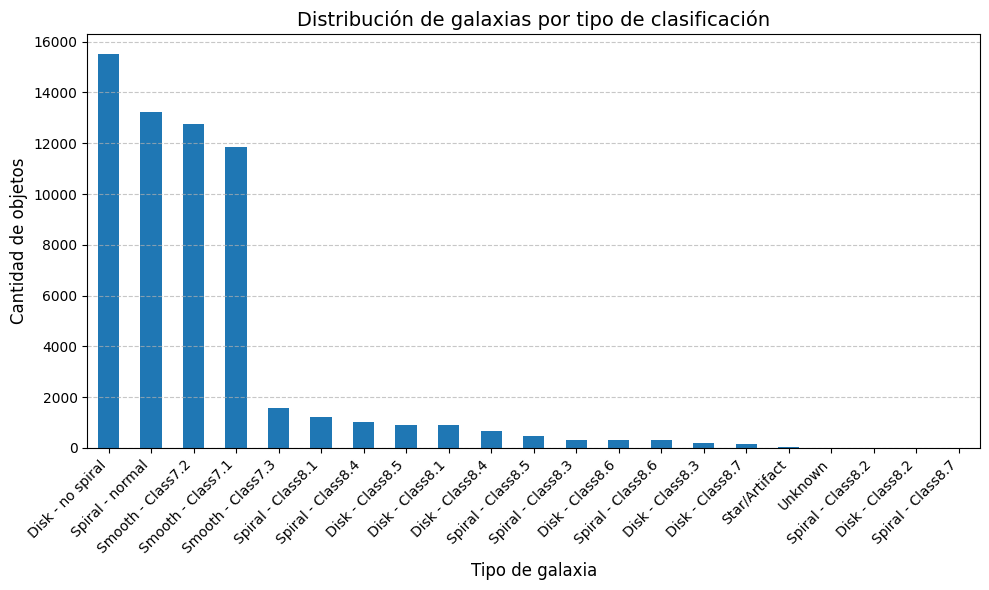

In [9]:
import matplotlib.pyplot as plt

# Contar cuántas galaxias hay por tipo de clasificación
conteo_labels = df["final_label"].value_counts()

# Crear gráfico de barras vertical
plt.figure(figsize=(10, 6))
conteo_labels.plot(kind='bar')

# Personalización del gráfico
plt.title("Distribución de galaxias por tipo de clasificación", fontsize=14)
plt.xlabel("Tipo de galaxia", fontsize=12)
plt.ylabel("Cantidad de objetos", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar gráfico
plt.show()


,Cantidad
label_grouped,
Smooth,26189
Disk,18720
Spiral,16610
Star/Artifact,44
Other,15
Total,61578


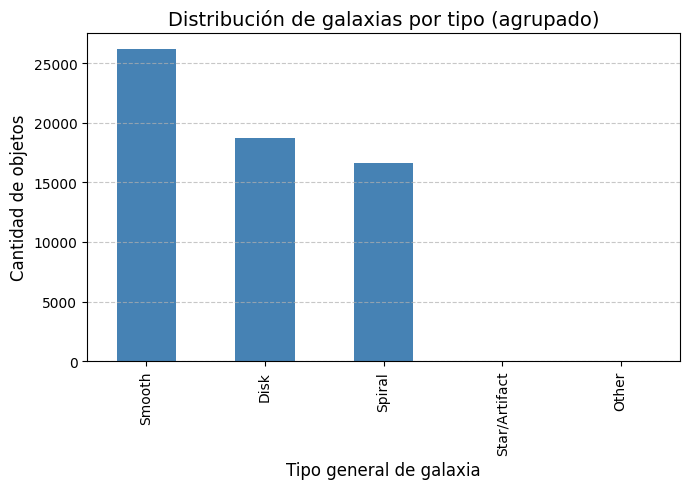

In [10]:
import matplotlib.pyplot as plt

# Agrupar las etiquetas finales en categorías generales
def agrupar_labels(label):
    if label.startswith("Smooth"):
        return "Smooth"
    elif label.startswith("Disk"):
        return "Disk"
    elif label.startswith("Spiral"):
        return "Spiral"
    elif "Star" in label:
        return "Star/Artifact"
    else:
        return "Other"

df["label_grouped"] = df["final_label"].apply(agrupar_labels)

# Contar cuántos objetos hay por grupo
conteo_grouped = df["label_grouped"].value_counts().sort_values(ascending=False)

# Mostrar tabla resumen con total
resumen = conteo_grouped.to_frame(name="Cantidad")
resumen.loc["Total"] = resumen["Cantidad"].sum()
display(resumen)

# Graficar barras verticales
plt.figure(figsize=(7,5))
conteo_grouped.plot(kind="bar", color="steelblue")
plt.title("Distribución de galaxias por tipo (agrupado)", fontsize=14)
plt.xlabel("Tipo general de galaxia", fontsize=12)
plt.ylabel("Cantidad de objetos", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


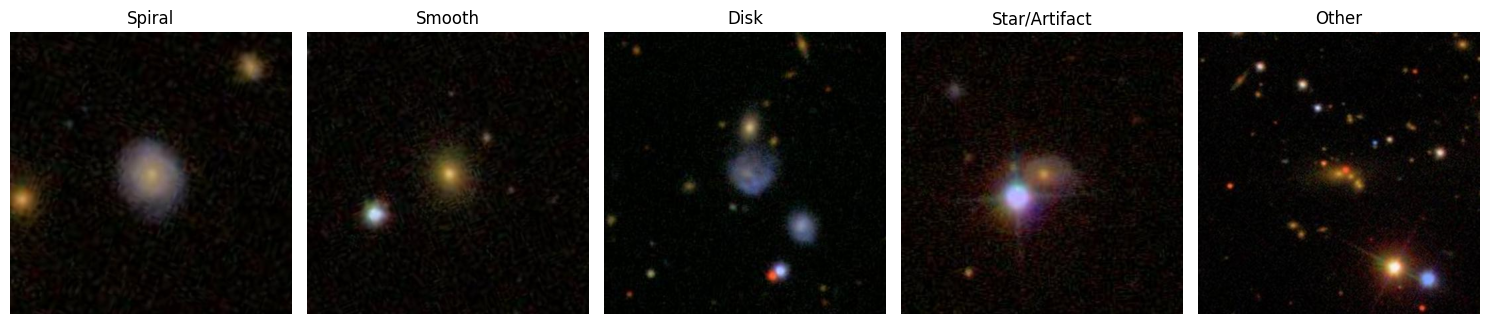

In [11]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Ruta a las imágenes
PATH_IMAGES = "images_training_rev1/"

# Verifica que exista la carpeta
if not os.path.exists(PATH_IMAGES):
    raise FileNotFoundError(f"No se encontró la carpeta: {PATH_IMAGES}")

# Asegúrate de tener la columna de IDs (ajusta el nombre si es distinto)
id_col = "GalaxyID"  # cambia si tu CSV usa otro nombre (p. ej., "id" o "galaxy_id")

# Obtener categorías únicas
categorias = df["label_grouped"].unique()

# Crear figura con subplots
plt.figure(figsize=(15, 4))

for i, cat in enumerate(categorias):
    subset = df[df["label_grouped"] == cat]
    if subset.empty:
        continue  # si no hay ejemplos, saltar

    # Elegir una galaxia al azar
    sample = subset.sample(1).iloc[0]
    galaxy_id = int(sample[id_col])

    # Construir la ruta de la imagen (por ejemplo: images_training_rev1/123456.jpg)
    img_path = os.path.join(PATH_IMAGES, f"{galaxy_id}.jpg")

    # Verificar que la imagen exista
    if not os.path.exists(img_path):
        print(f"No se encontró la imagen para {galaxy_id}")
        continue

    # Mostrar la imagen
    img = Image.open(img_path)
    plt.subplot(1, len(categorias), i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cat, fontsize=12)

plt.tight_layout()
plt.show()


,Cantidad
label_grouped,
Smooth,26189
Disk,18720
Spiral,16610
Star/Artifact,59
Total,61578


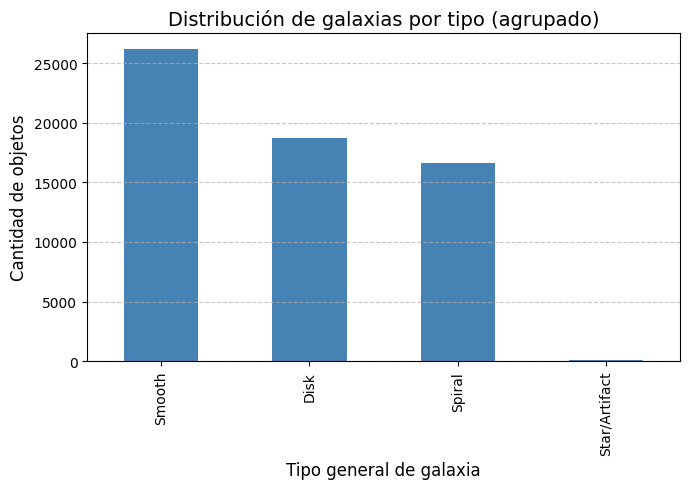

In [12]:
import matplotlib.pyplot as plt

# Agrupar las etiquetas finales en categorías generales
def agrupar_labels(label):
    if label.startswith("Smooth"):
        return "Smooth"
    elif label.startswith("Disk"):
        return "Disk"
    elif label.startswith("Spiral"):
        return "Spiral"
    elif "Star" in label or "Other" in label:
        # Une Star y Other en una sola categoría
        return "Star/Artifact"
    else:
        return "Star/Artifact"  # si hay alguna sin clasificar, la sumamos también aquí

# Aplicar agrupamiento
df["label_grouped"] = df["final_label"].apply(agrupar_labels)

# Contar cuántos objetos hay por grupo
conteo_grouped = df["label_grouped"].value_counts().sort_values(ascending=False)

# Mostrar tabla resumen con total
resumen = conteo_grouped.to_frame(name="Cantidad")
resumen.loc["Total"] = resumen["Cantidad"].sum()
display(resumen)

# Graficar barras verticales
plt.figure(figsize=(7,5))
conteo_grouped.plot(kind="bar", color="steelblue")
plt.title("Distribución de galaxias por tipo (agrupado)", fontsize=14)
plt.xlabel("Tipo general de galaxia", fontsize=12)
plt.ylabel("Cantidad de objetos", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


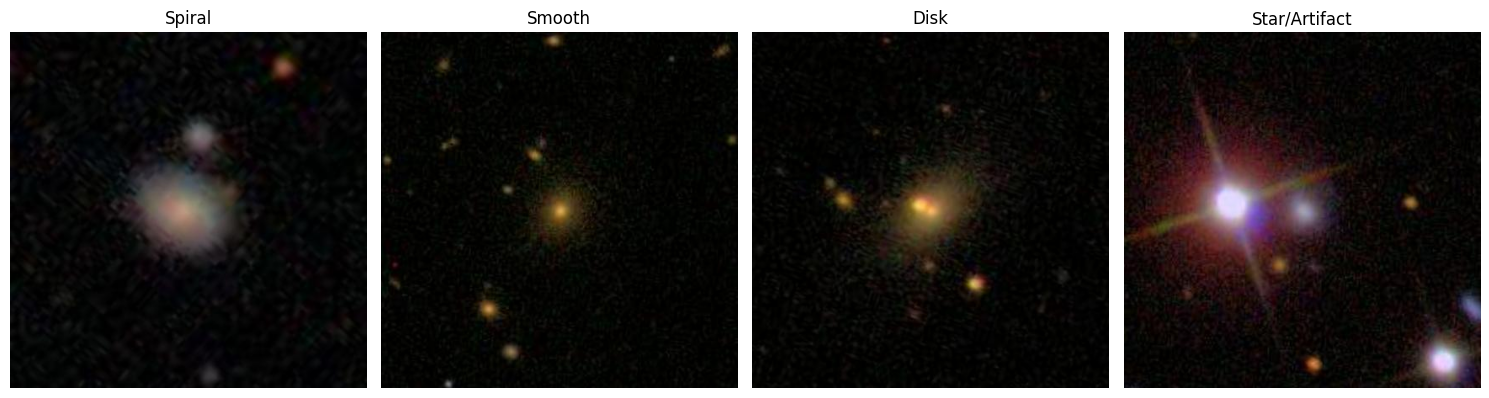

In [13]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Ruta a las imágenes
PATH_IMAGES = "images_training_rev1/"

# Verifica que exista la carpeta
if not os.path.exists(PATH_IMAGES):
    raise FileNotFoundError(f"No se encontró la carpeta: {PATH_IMAGES}")

# Asegúrate de tener la columna de IDs (ajusta el nombre si es distinto)
id_col = "GalaxyID"  # cambia si tu CSV usa otro nombre (p. ej., "id" o "galaxy_id")

# Obtener categorías únicas
categorias = df["label_grouped"].unique()

# Crear figura con subplots
plt.figure(figsize=(15, 4))

for i, cat in enumerate(categorias):
    subset = df[df["label_grouped"] == cat]
    if subset.empty:
        continue  # si no hay ejemplos, saltar

    # Elegir una galaxia al azar
    sample = subset.sample(1).iloc[0]
    galaxy_id = int(sample[id_col])

    # Construir la ruta de la imagen (por ejemplo: images_training_rev1/123456.jpg)
    img_path = os.path.join(PATH_IMAGES, f"{galaxy_id}.jpg")

    # Verificar que la imagen exista
    if not os.path.exists(img_path):
        print(f"No se encontró la imagen para {galaxy_id}")
        continue

    # Mostrar la imagen
    img = Image.open(img_path)
    plt.subplot(1, len(categorias), i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cat, fontsize=12)

plt.tight_layout()
plt.show()

In [14]:
# ==== Celda 1: Carga, muestreo y preprocesamiento ====
import os
import random
import time
import numpy as np
import pandas as pd
import cv2
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

PATH_IMAGES = "images_training_rev1/"
N_SAMPLES = 2000  # puedes aumentar más adelante

start_time = time.time()

# Verifica si el DataFrame 'df' ya existe; si no, cárgalo
if 'df' not in locals():
    df = pd.read_csv("training_solutions_rev1.csv")

# Usamos la columna con las clases ya agrupadas
if "label_grouped" not in df.columns:
    raise ValueError("Asegúrate de haber generado 'label_grouped' antes con el agrupamiento Smooth/Disk/Spiral/Other/Star.")

# Muestra 2000 imágenes aleatorias
df_sample = df.sample(n=N_SAMPLES, random_state=42)

# Filtra clases con al menos 2 muestras
conteo = df_sample["label_grouped"].value_counts()
valid_classes = conteo[conteo >= 2].index
df_sample = df_sample[df_sample["label_grouped"].isin(valid_classes)]

print("Imágenes seleccionadas:", len(df_sample))
print("Distribución por clase:\n", df_sample["label_grouped"].value_counts())

# Carga imágenes en escala de grises
imgs = []
labels = []

for idx, row in df_sample.iterrows():
    img_path = os.path.join(PATH_IMAGES, f"{row['GalaxyID']}.jpg")
    if os.path.exists(img_path):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, (64, 64))  # redimensiona
            imgs.append(img.flatten())      # a vector 1D
            labels.append(row["label_grouped"])

X = np.array(imgs)
y = np.array(labels)

print("Shape de X:", X.shape)
print("Clases detectadas:", np.unique(y))

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (reduce dimensionalidad al 95% de varianza)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape después de PCA:", X_pca.shape)

# Codificación de etiquetas
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

# División Train/Test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print("Shape X_train:", X_train.shape, "X_test:", X_test.shape)
print("Tiempo total preprocesamiento: {:.2f} s".format(time.time() - start_time))


Imágenes seleccionadas: 2000
Distribución por clase:
 label_grouped
Smooth           860
Disk             636
Spiral           501
Star/Artifact      3
Name: count, dtype: int64
Shape de X: (2000, 4096)
Clases detectadas: ['Disk' 'Smooth' 'Spiral' 'Star/Artifact']
Shape después de PCA: (2000, 856)
Shape X_train: (1600, 856) X_test: (400, 856)
Tiempo total preprocesamiento: 12.37 s


In [15]:
import numpy as np
import time
from skimage.color import rgb2gray

print("===> Preparando datos...")

# Si las imágenes son RGB, se convierten a escala de grises
if X_train.ndim == 4 and X_train.shape[-1] == 3:
    print("Convirtiendo imágenes a escala de grises...")
    X_train_gray = np.array([rgb2gray(img) for img in X_train])
    X_test_gray = np.array([rgb2gray(img) for img in X_test])
    X_train = X_train_gray.reshape(len(X_train_gray), -1)
    X_test = X_test_gray.reshape(len(X_test_gray), -1)
else:
    X_train = X_train.reshape(len(X_train), -1)
    X_test = X_test.reshape(len(X_test), -1)

print("Formas finales -> X_train:", X_train.shape, "| X_test:", X_test.shape)


===> Preparando datos...
Formas finales -> X_train: (1600, 856) | X_test: (400, 856)


In [16]:
import time
from sklearn.linear_model import LogisticRegression

print("===> Entrenando modelo Logistic Regression...")

# Inicio del cronómetro
start_time = time.time()

clf = LogisticRegression(
    max_iter=2000,
    solver="saga",            # eficiente y paralelizable
    multi_class="multinomial",
    n_jobs=-1,                # usa todos los núcleos disponibles
    random_state=42
)

clf.fit(X_train, y_train)

# Fin del cronómetro
elapsed = time.time() - start_time

print("Entrenamiento completado.")
print(f" Tiempo total de entrenamiento: {elapsed/60:.2f} minutos ({elapsed:.2f} segundos)")




===> Entrenando modelo Logistic Regression...


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Entrenamiento completado.
 Tiempo total de entrenamiento: 0.56 minutos (33.56 segundos)


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


===> Calculando predicciones...
=== Classification Report ===
               precision    recall  f1-score   support

         Disk       0.33      0.35      0.34       127
       Smooth       0.54      0.49      0.51       172
       Spiral       0.33      0.35      0.34       100
Star/Artifact       0.25      1.00      0.40         1

     accuracy                           0.41       400
    macro avg       0.36      0.55      0.40       400
 weighted avg       0.42      0.41      0.41       400



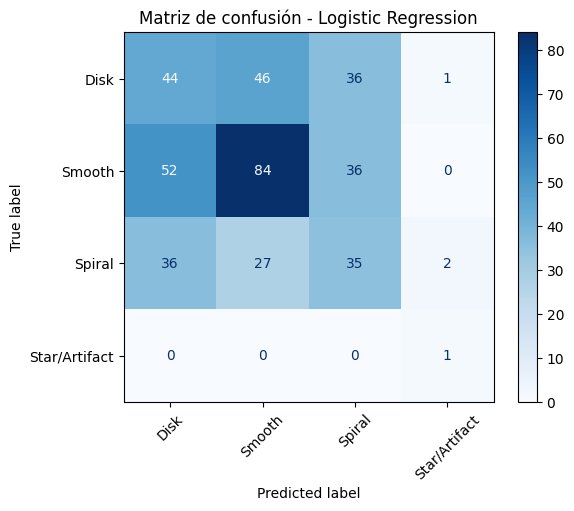

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("===> Calculando predicciones...")

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)

# Reporte general
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión - Logistic Regression")
plt.show()


In [18]:
import math
import numpy as np

print("\n=== Métricas detalladas por clase ===")

n_classes = len(class_names)
specificity = np.zeros(n_classes)
npv = np.zeros(n_classes)
gmean = np.zeros(n_classes)

for i in range(n_classes):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity[i] = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    npv[i] = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    gmean[i] = math.sqrt(sensitivity * specificity[i])
    print(f"{class_names[i]} → Sensitivity={sensitivity:.4f}, "
          f"Specificity={specificity[i]:.4f}, NPV={npv[i]:.4f}, G-Mean={gmean[i]:.4f}")



=== Métricas detalladas por clase ===
Disk → Sensitivity=0.3465, Specificity=0.6777, NPV=0.6903, G-Mean=0.4845
Smooth → Sensitivity=0.4884, Specificity=0.6798, NPV=0.6379, G-Mean=0.5762
Spiral → Sensitivity=0.3500, Specificity=0.7600, NPV=0.7782, G-Mean=0.5158
Star/Artifact → Sensitivity=1.0000, Specificity=0.9925, NPV=1.0000, G-Mean=0.9962


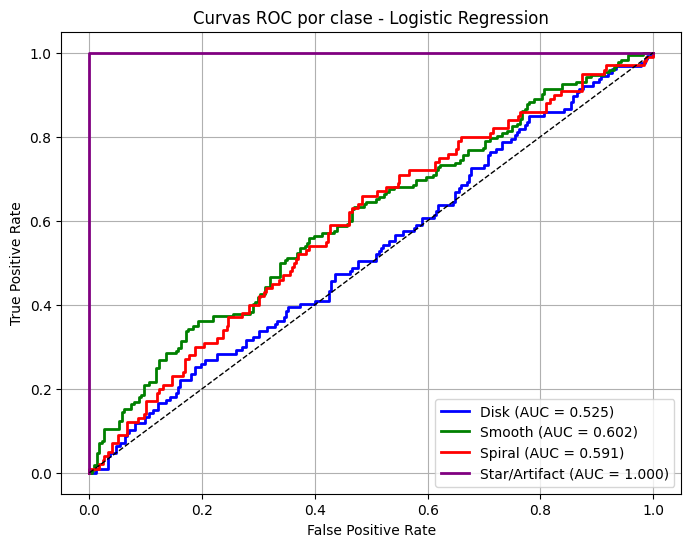

Mejor AUC (por clase): 1.0000


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

plt.figure(figsize=(8, 6))
colors = cycle(["blue", "green", "red", "purple", "orange"])
aucs = []

for i, color in zip(range(len(class_names)), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_val = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    aucs.append(auc_val)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{class_names[i]} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC por clase - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Mejor AUC (por clase): {np.nanmax(aucs):.4f}")


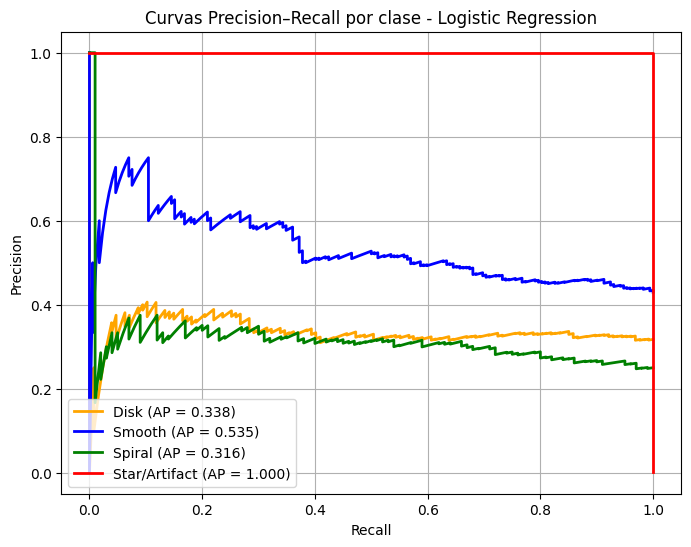

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))
for i, color in zip(range(len(class_names)), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(recall, precision, color=color, lw=2,
             label=f"{class_names[i]} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision–Recall por clase - Logistic Regression")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


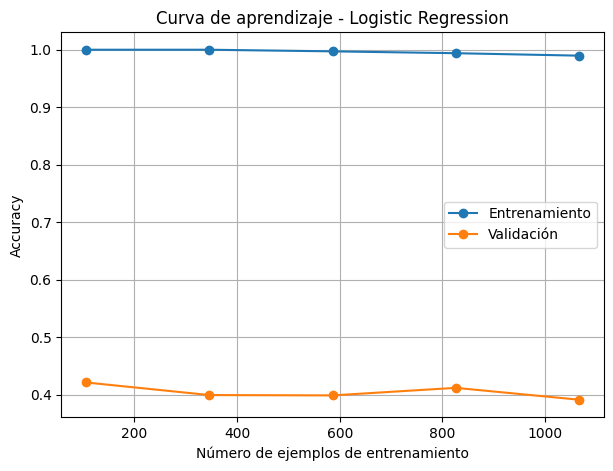

In [21]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    clf, X_train, y_train,
    cv=3,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring="accuracy"
)

train_scores_mean = train_scores.mean(axis=1)
val_scores_mean = val_scores.mean(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Entrenamiento")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validación")
plt.xlabel("Número de ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje - Logistic Regression")
plt.legend()
plt.grid()
plt.show()




In [22]:
import time
from sklearn.svm import SVC

print("===> Entrenando modelo SVM...")

# Iniciar temporizador
start_time = time.time()

# SVM con kernel lineal (puedes cambiar a 'rbf' o 'poly')
svm_clf = SVC(
    kernel='rbf',
    probability=True,  # necesario para ROC
    class_weight='balanced',
    random_state=42
)

svm_clf.fit(X_train, y_train)

# Fin del temporizador
elapsed = time.time() - start_time

print("Entrenamiento completado.")
print(f" Tiempo total de entrenamiento: {elapsed/60:.2f} minutos ({elapsed:.2f} segundos)")


===> Entrenando modelo SVM...
Entrenamiento completado.
 Tiempo total de entrenamiento: 0.04 minutos (2.22 segundos)


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print("===> Evaluando modelo SVM...")

y_pred_svm = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)

# Reporte de clasificación
print("\n Classification Report - SVM:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

# Matriz de confusión numérica
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("\nMatriz de confusión:\n", cm_svm)


===> Evaluando modelo SVM...

 Classification Report - SVM:
               precision    recall  f1-score   support

         Disk       0.42      0.54      0.47       127
       Smooth       0.73      0.52      0.61       172
       Spiral       0.43      0.49      0.46       100
Star/Artifact       0.00      0.00      0.00         1

     accuracy                           0.52       400
    macro avg       0.39      0.39      0.38       400
 weighted avg       0.55      0.52      0.52       400


Matriz de confusión:
 [[68 22 37  0]
 [54 89 29  0]
 [40 11 49  0]
 [ 1  0  0  0]]


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [25]:
import numpy as np
import math

print("===> Métricas adicionales por clase (SVM):")

n_classes = len(class_names)
specificity = np.zeros(n_classes)
npv = np.zeros(n_classes)
gmean = np.zeros(n_classes)

for i in range(n_classes):
    TP = cm_svm[i, i]
    FP = cm_svm[:, i].sum() - TP
    FN = cm_svm[i, :].sum() - TP
    TN = cm_svm.sum() - (TP + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity[i] = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    npv[i] = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    gmean[i] = math.sqrt(sensitivity * specificity[i]) if sensitivity >= 0 else 0.0

    print(f"Clase {class_names[i]}:")
    print(f"  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  Specificity: {specificity[i]:.4f}")
    print(f"  NPV: {npv[i]:.4f}")
    print(f"  G-Mean: {gmean[i]:.4f}\n")


===> Métricas adicionales por clase (SVM):
Clase Disk:
  Sensitivity (Recall): 0.5354
  Specificity: 0.6520
  NPV: 0.7511
  G-Mean: 0.5909

Clase Smooth:
  Sensitivity (Recall): 0.5174
  Specificity: 0.8553
  NPV: 0.7014
  G-Mean: 0.6652

Clase Spiral:
  Sensitivity (Recall): 0.4900
  Specificity: 0.7800
  NPV: 0.8211
  G-Mean: 0.6182

Clase Star/Artifact:
  Sensitivity (Recall): 0.0000
  Specificity: 1.0000
  NPV: 0.9975
  G-Mean: 0.0000



===> Generando curvas ROC...


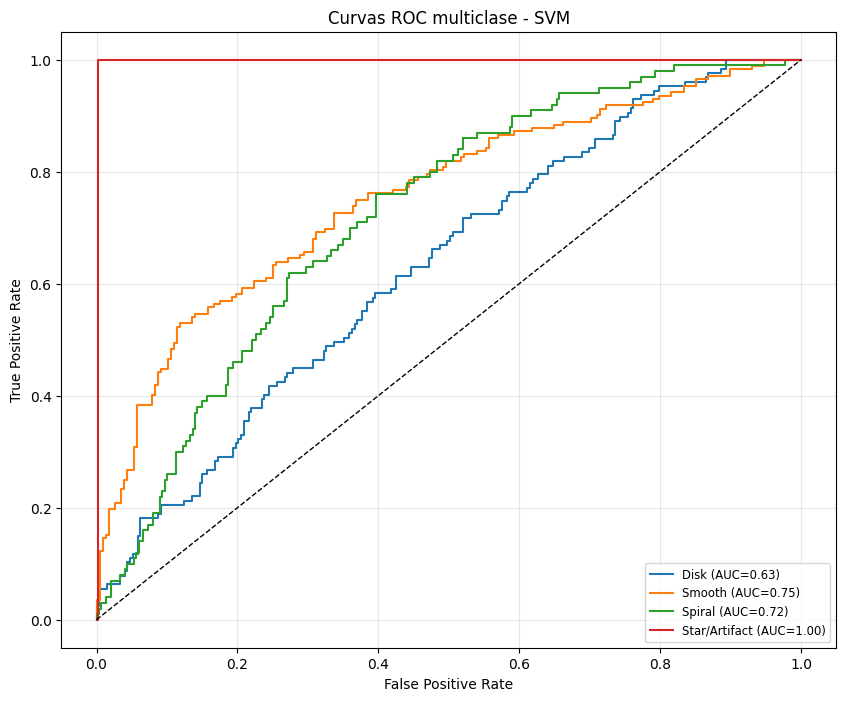

Mejor AUC (por clase): 0.9974937343358397


In [25]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print("===> Generando curvas ROC...")

y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

aucs = []
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_svm[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba_svm[:, i])
    aucs.append(auc)
    plt.plot(fpr, tpr, lw=1.5, label=f"{class_names[i]} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("Curvas ROC multiclase - SVM")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize='small')
plt.grid(alpha=0.3)
plt.show()

print("Mejor AUC (por clase):", np.nanmax(aucs))


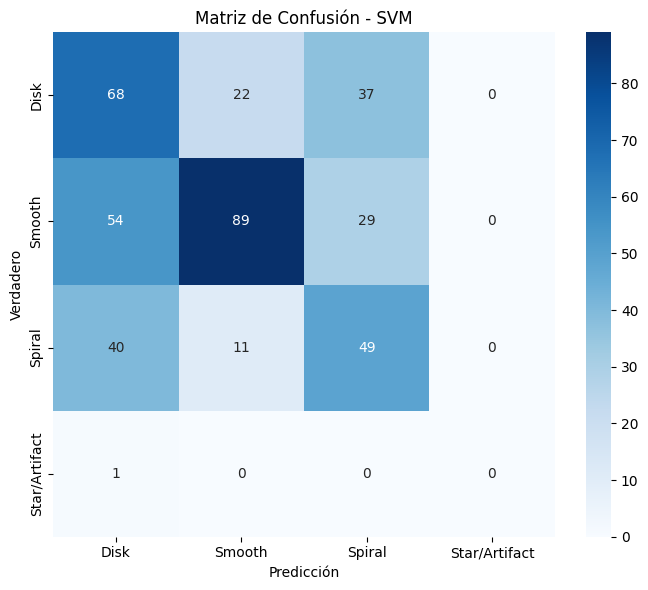

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión - SVM")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.tight_layout()
plt.show()


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


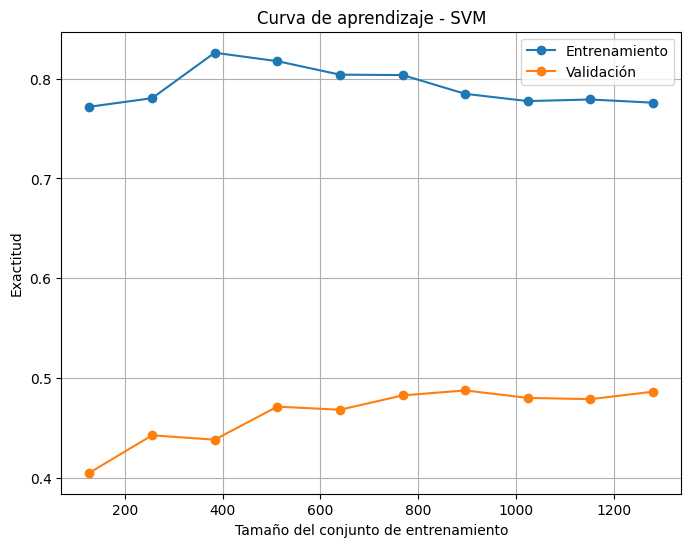

In [27]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    svm_clf, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', label='Entrenamiento')
plt.plot(train_sizes, val_mean, 'o-', label='Validación')
plt.title('Curva de aprendizaje - SVM')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)
plt.show()


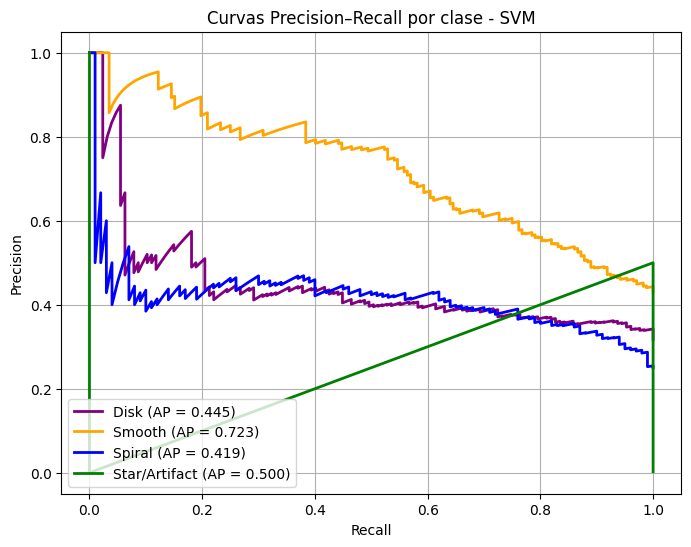

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Obtener las probabilidades del modelo SVM
y_proba_svm = svm_clf.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i, color in zip(range(len(class_names)), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_svm[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba_svm[:, i])
    plt.plot(recall, precision, color=color, lw=2,
             label=f"{class_names[i]} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision–Recall por clase - SVM")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


In [29]:
import time
from sklearn.tree import DecisionTreeClassifier

print("===> Entrenando modelo Decision Tree...")

# Iniciar temporizador
start_time = time.time()

# Crear y entrenar el modelo
tree_clf = DecisionTreeClassifier(
    criterion='entropy',      # también puedes usar 'gini'
    max_depth=None,           # limitar si se desea la profundidad del árbol
    class_weight='balanced',  # útil para clases desbalanceadas
    random_state=42
)

tree_clf.fit(X_train, y_train)

# Fin del temporizador
elapsed = time.time() - start_time

print("Entrenamiento completado.")
print(f" Tiempo total de entrenamiento: {elapsed/60:.2f} minutos ({elapsed:.2f} segundos)")


===> Entrenando modelo Decision Tree...
Entrenamiento completado.
 Tiempo total de entrenamiento: 0.03 minutos (1.91 segundos)


===> Evaluando modelo Decision Tree...

Classification Report - Decision Tree:
               precision    recall  f1-score   support

         Disk       0.36      0.35      0.36       127
       Smooth       0.51      0.55      0.53       172
       Spiral       0.32      0.28      0.30       100
Star/Artifact       0.00      0.00      0.00         1

     accuracy                           0.42       400
    macro avg       0.30      0.30      0.30       400
 weighted avg       0.41      0.42      0.42       400


Matriz de confusión:
 [[45 51 30  1]
 [48 95 29  0]
 [31 40 28  1]
 [ 0  1  0  0]]


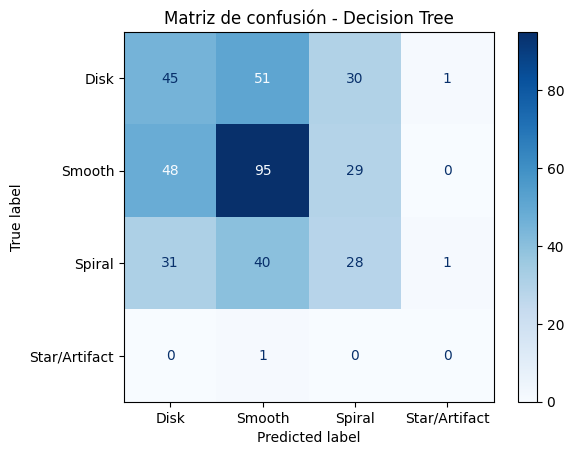


Métricas adicionales por clase:

Disk:
  Sensitivity (Recall) = 0.3543
  Specificity          = 0.7106
  NPV                  = 0.7029
  G-Mean               = 0.5018

Smooth:
  Sensitivity (Recall) = 0.5523
  Specificity          = 0.5965
  NPV                  = 0.6385
  G-Mean               = 0.5740

Spiral:
  Sensitivity (Recall) = 0.2800
  Specificity          = 0.8033
  NPV                  = 0.7700
  G-Mean               = 0.4743

Star/Artifact:
  Sensitivity (Recall) = 0.0000
  Specificity          = 0.9950
  NPV                  = 0.9975
  G-Mean               = 0.0000


In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

print("===> Evaluando modelo Decision Tree...")

# Predicciones y probabilidades
y_pred_tree = tree_clf.predict(X_test)
y_proba_tree = tree_clf.predict_proba(X_test)

# Reporte de clasificación
print("\nClassification Report - Decision Tree:")
print(classification_report(y_test, y_pred_tree, target_names=class_names))

# Matriz de confusión
cm_tree = confusion_matrix(y_test, y_pred_tree)
print("\nMatriz de confusión:\n", cm_tree)

# Visualización de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Decision Tree")
plt.show()

# =============================
# Métricas adicionales (por clase)
# =============================
print("\nMétricas adicionales por clase:")

for i, name in enumerate(class_names):
    TP = cm_tree[i, i]
    FP = cm_tree[:, i].sum() - TP
    FN = cm_tree[i, :].sum() - TP
    TN = cm_tree.sum() - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # Recall
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0
    g_mean = np.sqrt(sensitivity * specificity)

    print(f"\n{name}:")
    print(f"  Sensitivity (Recall) = {sensitivity:.4f}")
    print(f"  Specificity          = {specificity:.4f}")
    print(f"  NPV                  = {npv:.4f}")
    print(f"  G-Mean               = {g_mean:.4f}")


===> Curva de aprendizaje - Decision Tree


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


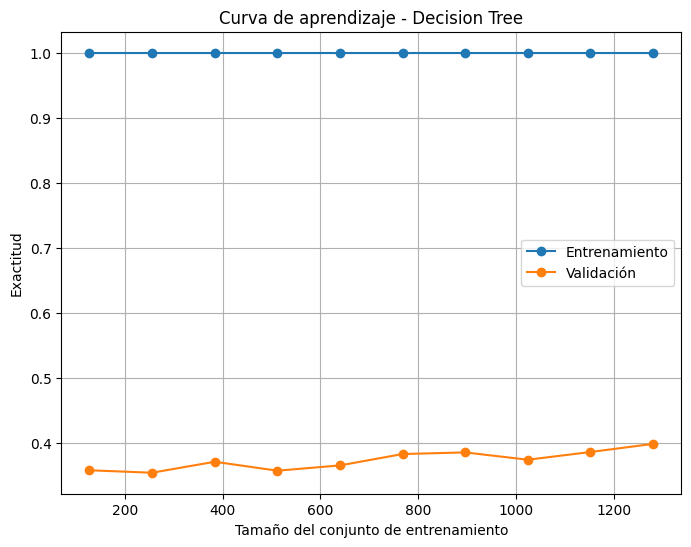

In [31]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

print("===> Curva de aprendizaje - Decision Tree")

train_sizes, train_scores, val_scores = learning_curve(
    tree_clf, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', label='Entrenamiento')
plt.plot(train_sizes, val_mean, 'o-', label='Validación')
plt.title('Curva de aprendizaje - Decision Tree')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)
plt.show()


===> Curvas Precision–Recall - Decision Tree


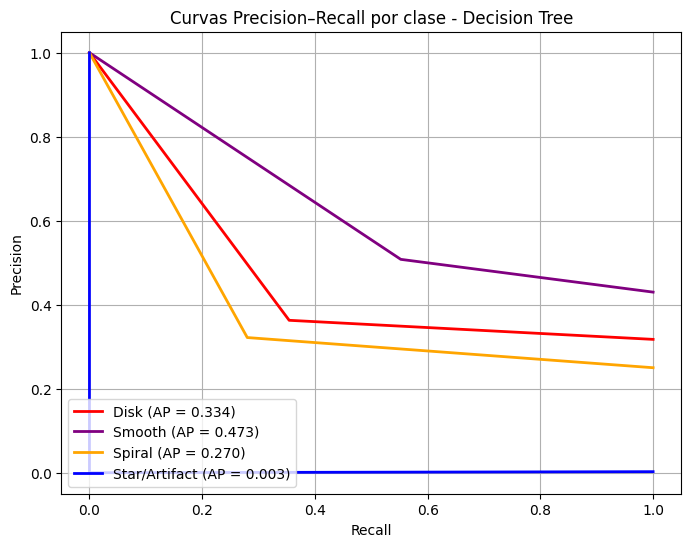

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

print("===> Curvas Precision–Recall - Decision Tree")

plt.figure(figsize=(8, 6))
for i, color in zip(range(len(class_names)), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_tree[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba_tree[:, i])
    plt.plot(recall, precision, color=color, lw=2,
             label=f"{class_names[i]} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision–Recall por clase - Decision Tree")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


===> Curvas ROC - Decision Tree


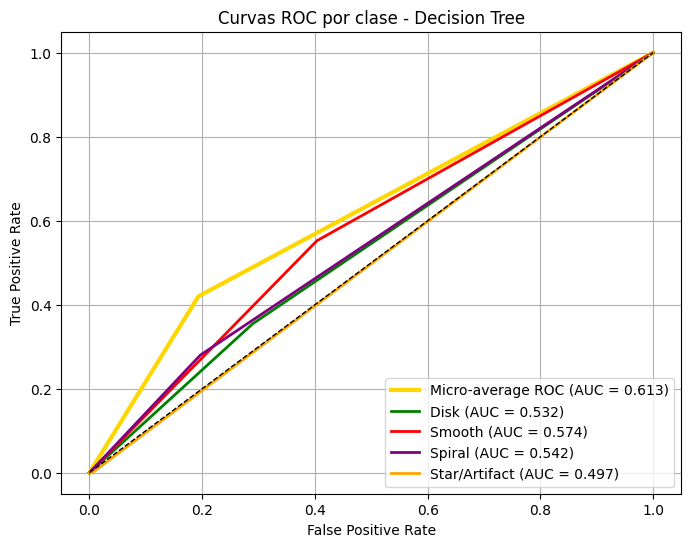

In [33]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

print("===> Curvas ROC - Decision Tree")

# Calcular curvas ROC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_tree[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Promedio micro (todas las clases juntas)
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba_tree.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(
    fpr["micro"], tpr["micro"],
    label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
    color='gold', linewidth=3
)

for i, color in zip(range(len(class_names)), colors):
    plt.plot(
        fpr[i], tpr[i],
        color=color, lw=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("Curvas ROC por clase - Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [34]:
import time
from sklearn.linear_model import SGDClassifier

print("===> Entrenando modelo Gradient Descent...")

# Iniciar temporizador
start_time = time.time()

# Clasificador con gradiente descendente (usando regresión logística como base)
gd_clf = SGDClassifier(
    loss='log_loss',        # para regresión logística (puedes usar 'hinge' para SVM lineal)
    penalty='l2',           # regularización
    max_iter=1000,
    learning_rate='optimal',
    class_weight='balanced',
    random_state=42
)

gd_clf.fit(X_train, y_train)

# Fin del temporizador
elapsed = time.time() - start_time
print("Entrenamiento completado.")
print(f" Tiempo total de entrenamiento: {elapsed/60:.2f} minutos ({elapsed:.2f} segundos)")


===> Entrenando modelo Gradient Descent...
Entrenamiento completado.
 Tiempo total de entrenamiento: 0.00 minutos (0.29 segundos)


===> Evaluando modelo Gradient Descent...

 Classification Report - Gradient Descent:
               precision    recall  f1-score   support

         Disk       0.37      0.29      0.33       127
       Smooth       0.50      0.35      0.41       172
       Spiral       0.38      0.18      0.24       100
Star/Artifact       0.01      1.00      0.02         1

     accuracy                           0.29       400
    macro avg       0.32      0.46      0.25       400
 weighted avg       0.43      0.29      0.34       400


Matriz de confusión:
 [[37 37 17 36]
 [32 61 12 67]
 [31 24 18 27]
 [ 0  0  0  1]]


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_base.py:396: RuntimeWarning: invalid value encountered in divide
  prob /= prob.sum(axis=1).reshape((prob.shape[0], -1))


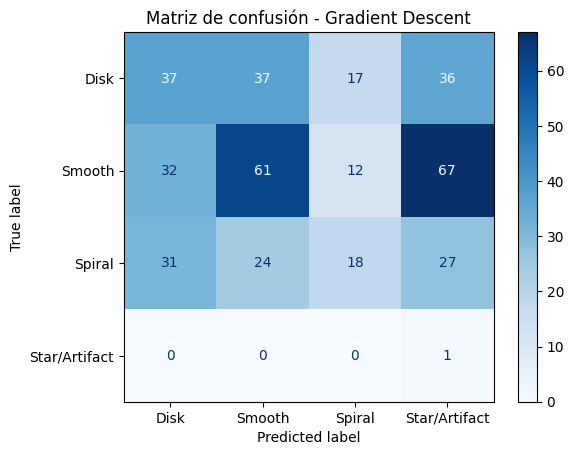


 Métricas adicionales por clase:

Disk:
  Sensitivity (Recall) = 0.2913
  Specificity          = 0.7692
  NPV                  = 0.7000
  G-Mean               = 0.4734

Smooth:
  Sensitivity (Recall) = 0.3547
  Specificity          = 0.7325
  NPV                  = 0.6007
  G-Mean               = 0.5097

Spiral:
  Sensitivity (Recall) = 0.1800
  Specificity          = 0.9033
  NPV                  = 0.7677
  G-Mean               = 0.4032

Star/Artifact:
  Sensitivity (Recall) = 1.0000
  Specificity          = 0.6742
  NPV                  = 1.0000
  G-Mean               = 0.8211


In [35]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

print("===> Evaluando modelo Gradient Descent...")

# Predicciones y probabilidades
y_pred_gd = gd_clf.predict(X_test)

# Algunas versiones de SGDClassifier no tienen predict_proba() sino decision_function()
if hasattr(gd_clf, "predict_proba"):
    y_proba_gd = gd_clf.predict_proba(X_test)
else:
    from sklearn.utils.extmath import softmax
    y_proba_gd = softmax(gd_clf.decision_function(X_test))

# Reporte de clasificación
print("\n Classification Report - Gradient Descent:")
print(classification_report(y_test, y_pred_gd, target_names=class_names))

# Matriz de confusión
cm_gd = confusion_matrix(y_test, y_pred_gd)
print("\nMatriz de confusión:\n", cm_gd)

# Visualización de la matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gd, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Gradient Descent")
plt.show()

# =============================
# Métricas adicionales (por clase)
# =============================
print("\n Métricas adicionales por clase:")

for i, name in enumerate(class_names):
    TP = cm_gd[i, i]
    FP = cm_gd[:, i].sum() - TP
    FN = cm_gd[i, :].sum() - TP
    TN = cm_gd.sum() - (TP + FP + FN)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0
    g_mean = np.sqrt(sensitivity * specificity)

    print(f"\n{name}:")
    print(f"  Sensitivity (Recall) = {sensitivity:.4f}")
    print(f"  Specificity          = {specificity:.4f}")
    print(f"  NPV                  = {npv:.4f}")
    print(f"  G-Mean               = {g_mean:.4f}")


===> Curva de aprendizaje - Gradient Descent


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


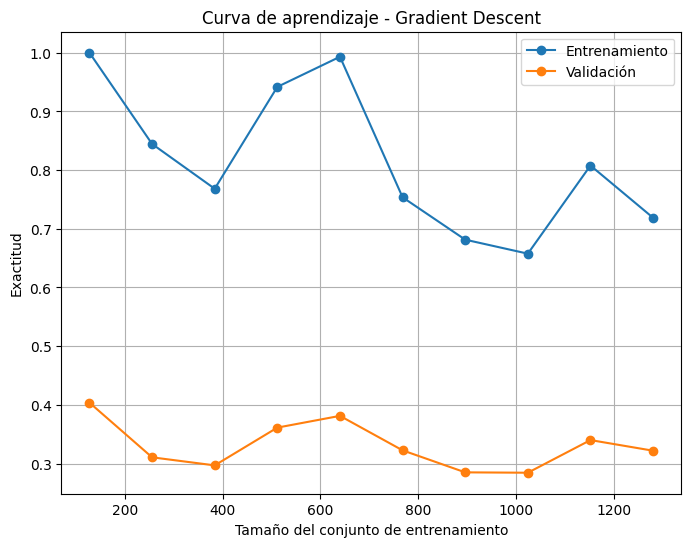

In [36]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

print("===> Curva de aprendizaje - Gradient Descent")

train_sizes, train_scores, val_scores = learning_curve(
    gd_clf, X_train, y_train, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, 'o-', label='Entrenamiento')
plt.plot(train_sizes, val_mean, 'o-', label='Validación')
plt.title('Curva de aprendizaje - Gradient Descent')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
# Reemplazar valores no finitos (NaN, inf, -inf) por 0
y_proba_gd = np.nan_to_num(y_proba_gd, nan=0.0, posinf=1.0, neginf=0.0)


===> Curvas Precision–Recall - Gradient Descent


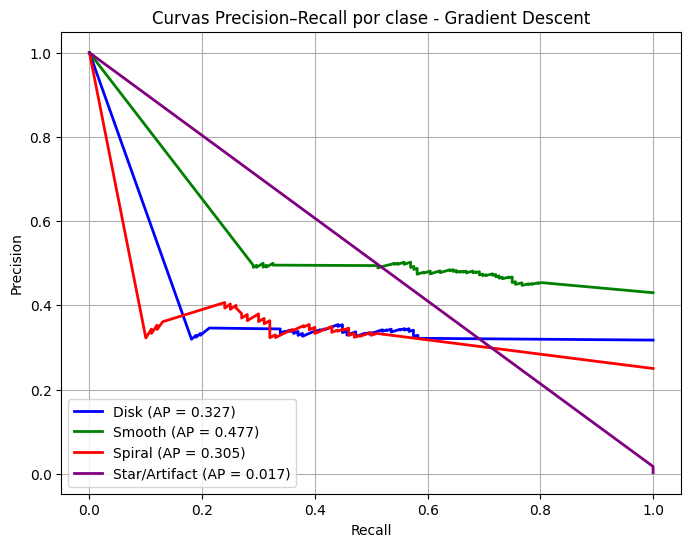

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score

print("===> Curvas Precision–Recall - Gradient Descent")

plt.figure(figsize=(8, 6))
for i, color in zip(range(len(class_names)), colors):
    # Revisar si hay variación en las probabilidades
    if np.unique(y_proba_gd[:, i]).size < 2:
        print(f"⚠️ Clase {class_names[i]} omitida (sin variación en probabilidades)")
        continue

    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_gd[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba_gd[:, i])
    plt.plot(recall, precision, color=color, lw=2,
             label=f"{class_names[i]} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision–Recall por clase - Gradient Descent")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()


===> Curvas ROC - Gradient Descent


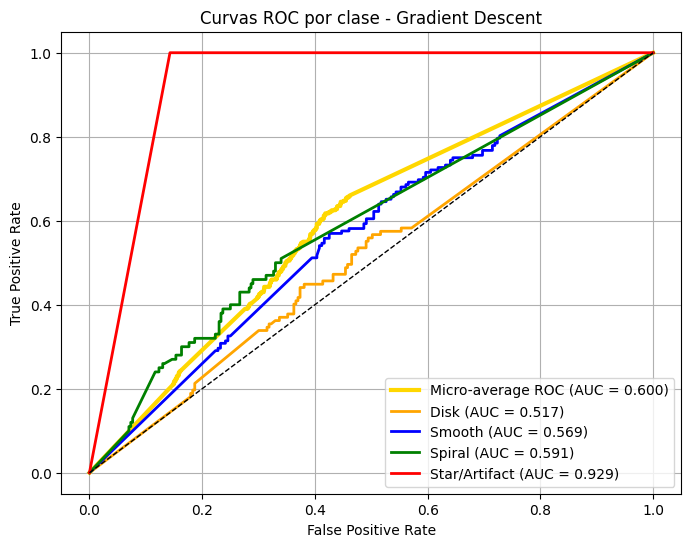

In [39]:
from sklearn.metrics import roc_curve, auc

print("===> Curvas ROC - Gradient Descent")

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_gd[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Promedio micro
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba_gd.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
         color='gold', linewidth=3)

for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i],
             color=color, lw=2,
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("Curvas ROC por clase - Gradient Descent")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [40]:
import os
import time
import numpy as np
import pandas as pd
import cv2
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

PATH_IMAGES = "images_training_rev1/"
# N_SAMPLES = 2000  # <--- ELIMINADO: Procesaremos el total

# Comprobación de que las variables necesarias existan desde el código anterior
if 'df' not in locals():
    raise NameError("El DataFrame 'df' (soluciones) no está cargado.")
if "label_grouped" not in df.columns:
    raise ValueError("Asegúrate de haber generado la columna 'label_grouped' antes de ejecutar esta celda.")

# --- 1. Preparación de Datos ---
start_time = time.time()

# NO se realiza muestreo: se usa el DataFrame 'df' completo
df_total = df.copy()

# Filtra clases con al menos 2 muestras (aunque con el total esto ya no debería ser problema)
conteo = df_total["label_grouped"].value_counts()
valid_classes = conteo[conteo >= 2].index
df_total = df_total[df_total["label_grouped"].isin(valid_classes)]

print("Imágenes totales a procesar:", len(df_total))
print("Distribución por clase:\n", df_total["label_grouped"].value_counts())

# --- 2. Carga y Redimensionamiento de Imágenes ---
imgs = []
labels = []
TARGET_SIZE = (64, 64) # Usamos 64x64 como en tu celda anterior (4096 features)

for idx, row in df_total.iterrows():
    img_path = os.path.join(PATH_IMAGES, f"{row['GalaxyID']}.jpg")
    
    # Usamos cv2.imread para cargar y preprocesar eficientemente
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA) # redimensiona
        imgs.append(img.flatten())                                       # a vector 1D
        labels.append(row["label_grouped"])
    # else:
    #     print(f"Advertencia: Archivo no encontrado o inválido para GalaxyID {row['GalaxyID']}")

X = np.array(imgs)
y = np.array(labels)

print("\nShape de X (imágenes aplanadas):", X.shape)
print("Clases detectadas:", np.unique(y))

# --- 3. Escalado y PCA ---
# El escalado y PCA son VITALES para que la Regresión Logística pueda manejar X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (reduce dimensionalidad, manteniendo el 95% de la varianza)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Shape después de PCA (nuevas features):", X_pca.shape)
print(f"Dimensionalidad reducida de {X.shape[1]} a {X_pca.shape[1]} features.")

# --- 4. Codificación de Etiquetas y División Train/Test ---
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = le.classes_

# División Train/Test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print("\nShape X_train:", X_train.shape, "X_test:", X_test.shape)
print("Tiempo total preprocesamiento: {:.2f} segundos".format(time.time() - start_time))

Imágenes totales a procesar: 61578
Distribución por clase:
 label_grouped
Smooth           26189
Disk             18720
Spiral           16610
Star/Artifact       59
Name: count, dtype: int64

Shape de X (imágenes aplanadas): (61578, 4096)
Clases detectadas: ['Disk' 'Smooth' 'Spiral' 'Star/Artifact']
Shape después de PCA (nuevas features): (61578, 1008)
Dimensionalidad reducida de 4096 a 1008 features.

Shape X_train: (49262, 1008) X_test: (12316, 1008)
Tiempo total preprocesamiento: 369.86 segundos


In [41]:
# Esta celda no necesita la conversión a escala de grises ni el reshape, ya que
# X_pca (proveniente de la celda anterior) ya es 2D (muestras x features_pca).

print("Formas finales -> X_train:", X_train.shape, "| X_test:", X_test.shape)

Formas finales -> X_train: (49262, 1008) | X_test: (12316, 1008)


In [42]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

print("===> Entrenando modelo Logistic Regression con el total de imágenes (PCA features)...")

# Inicio del cronómetro
start_time = time.time()

clf = LogisticRegression(
    max_iter=3000,           # Aumentamos max_iter por el mayor volumen de datos
    solver="saga",           # eficiente y paralelizable, soporta multinomial y L1/L2
    multi_class="multinomial",
    n_jobs=-1,               # usa todos los núcleos disponibles
    random_state=42
)

clf.fit(X_train, y_train)

# Fin del cronómetro
elapsed = time.time() - start_time

print("Entrenamiento completado.")
print(f" Tiempo total de entrenamiento: {elapsed/60:.2f} minutos ({elapsed:.2f} segundos)")

# Evaluación final
y_pred_lr = clf.predict(X_test)
print("\nReporte de Clasificación (Usando PCA de Píxeles 64x64):")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

===> Entrenando modelo Logistic Regression con el total de imágenes (PCA features)...


C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Entrenamiento completado.
 Tiempo total de entrenamiento: 30.67 minutos (1839.97 segundos)

Reporte de Clasificación (Usando PCA de Píxeles 64x64):
               precision    recall  f1-score   support

         Disk       0.45      0.32      0.37      3744
       Smooth       0.58      0.72      0.64      5238
       Spiral       0.56      0.52      0.54      3322
Star/Artifact       0.38      0.25      0.30        12

     accuracy                           0.54     12316
    macro avg       0.49      0.45      0.46     12316
 weighted avg       0.53      0.54      0.53     12316



C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


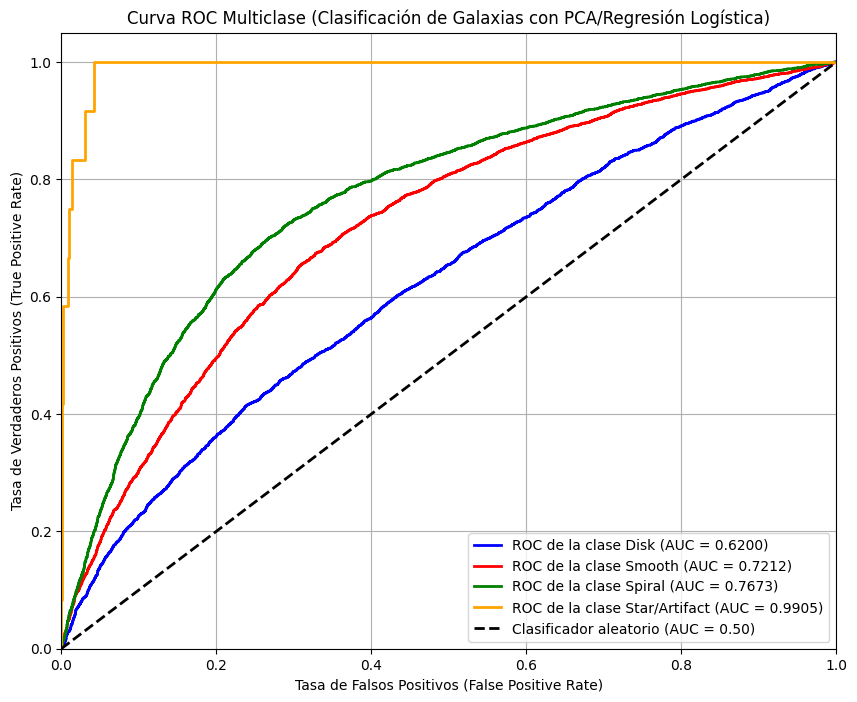

In [43]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# Se asume que las variables X_test, y_test, y_enc, class_names y el modelo clf están disponibles
# (creadas en la Celda 1 y Celda 2 del entrenamiento con la totalidad de imágenes).

# --- 1. Preparar las etiquetas 'y' para el formato multiclase (binarización) ---

# Convertir las etiquetas de prueba (y_test) a un formato binario OvR.
y_test_binarized = label_binarize(y_test, classes=np.unique(y_enc))
n_classes = y_test_binarized.shape[1]

# --- 2. Obtener las probabilidades de predicción para cada clase ---

# Usamos el modelo 'clf' entrenado con todas las imágenes (PCA features)
y_score = clf.predict_proba(X_test)

# --- 3. Calcular la Curva ROC y el Área bajo la Curva (AUC) para cada clase ---

fpr = dict()  # Tasa de Falsos Positivos
tpr = dict()  # Tasa de Verdaderos Positivos
roc_auc = dict()

for i in range(n_classes):
    # Calcula fpr y tpr comparando la columna 'i' binarizada vs las probabilidades de la clase 'i'
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 4. Graficar la Curva ROC OvR ---

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple'] 
# Usamos hasta 5 colores por si la etiqueta 'Other' sigue presente

for i, color in zip(range(n_classes), colors):
    # Aseguramos que la clase exista en class_names
    if i < len(class_names):
        label_name = class_names[i]
    else:
        label_name = f'Clase {i}'

    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC de la clase {label_name} (AUC = {roc_auc[i]:.4f})')

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador aleatorio (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (False Positive Rate)')
plt.ylabel('Tasa de Verdaderos Positivos (True Positive Rate)')
plt.title('Curva ROC Multiclase (Clasificación de Galaxias con PCA/Regresión Logística)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

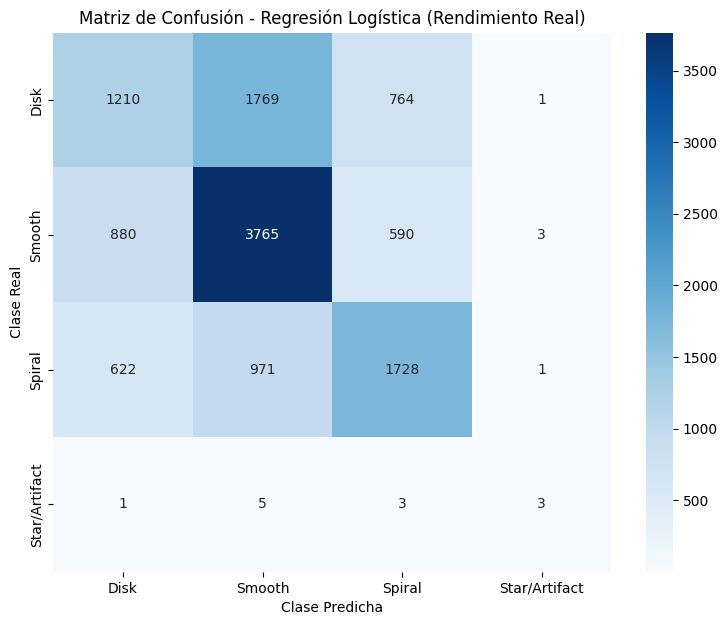


--- Métricas Detalladas por Clase ---


,precision,Sensitivity (Recall),f1-score,support,Specificity,NPV,G-Mean
Disk,0.4460,0.3232,0.3748,3744.0000,0.8247,0.7361,0.5163
Smooth,0.5783,0.7188,0.6410,5238.0000,0.6122,0.7463,0.6633
Spiral,0.5601,0.5202,0.5394,3322.0000,0.8491,0.8273,0.6646
Star/Artifact,0.3750,0.2500,0.3000,12.0000,0.9996,0.9993,0.4999



--- Métricas Promedio y Exactitud General ---


,precision,Sensitivity (Recall),f1-score
accuracy,0.5445,0.5445,0.5445
macro avg,0.4899,0.4530,0.4638
weighted avg,0.5330,0.5445,0.5323


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ⚠️ ADVERTENCIA: Este código asume que las variables del modelo entrenado
# y los datos de prueba REALES (sin data leakage) están cargadas:
# - clf: El modelo LogisticRegression entrenado.
# - X_test, y_test: Conjuntos de prueba.
# - class_names: Los nombres de las etiquetas (ej., ['Disk', 'Smooth', 'Spiral', 'Star/Artifact']).

# -------------------------------------------------------------------------
# 1. Predicciones y Matriz de Confusión
# -------------------------------------------------------------------------

# Realizar predicciones
y_pred_clf = clf.predict(X_test)

# Calcular la matriz de confusión
conf_matrix_clf = confusion_matrix(y_test, y_pred_clf)

# -------------------------------------------------------------------------
# 2. Cálculo de Métricas Detalladas por Clase
# -------------------------------------------------------------------------

# Obtener el reporte estándar de Sklearn como un diccionario
report = classification_report(y_test, y_pred_clf, target_names=class_names, output_dict=True)

# Inicializar diccionario para métricas personalizadas
metrics_custom = {}
n_classes = len(class_names)

for i, class_name in enumerate(class_names):
    
    # Extracción de valores de la Matriz de Confusión para OvR
    TP = conf_matrix_clf[i, i]
    FN = conf_matrix_clf[i, :].sum() - TP
    FP = conf_matrix_clf[:, i].sum() - TP
    TN = conf_matrix_clf.sum() - (TP + FN + FP)
    
    # Cálculo de Métricas Adicionales (usando 1e-10 para evitar división por cero)
    sensitivity = TP / (TP + FN + 1e-10) # Igual a Recall
    specificity = TN / (TN + FP + 1e-10)
    npv = TN / (TN + FN + 1e-10)
    g_mean = np.sqrt(sensitivity * specificity)
    
    metrics_custom[class_name] = {
        'Specificity': specificity,
        'NPV': npv,
        'G-Mean': g_mean
    }

# -------------------------------------------------------------------------
# 3. Construcción y Visualización de Tablas
# -------------------------------------------------------------------------

# Convertir el reporte estándar a DataFrame y renombrar 'recall'
df_standard = pd.DataFrame(report).transpose()
df_standard = df_standard.rename(columns={'recall': 'Sensitivity (Recall)'})

# Separar métricas promedio y de exactitud
df_avg = df_standard.loc[['accuracy', 'macro avg', 'weighted avg']].copy()
df_classes = df_standard.drop(['accuracy', 'macro avg', 'weighted avg']).copy()

# Agregar las métricas personalizadas al DataFrame de clases
df_custom = pd.DataFrame(metrics_custom).transpose()
df_final_classes = df_classes.join(df_custom)

# -------------------------------------------------------------------------
# 4. Resultados Finales
# -------------------------------------------------------------------------

# A. Visualizar la Matriz de Confusión
plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix_clf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Regresión Logística (Rendimiento Real)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

# B. Imprimir Métricas Detalladas por Clase
print("\n--- Métricas Detalladas por Clase ---")
# Mostrar todas las columnas solicitadas
display(df_final_classes.style.format("{:.4f}"))

# C. Imprimir Métricas Promedio y Exactitud General
print("\n--- Métricas Promedio y Exactitud General ---")
# El 'support' de 'accuracy' no tiene sentido; lo eliminamos para claridad.
df_avg = df_avg.drop(columns=['support'], errors='ignore') 
display(df_avg.style.format({
    'precision': '{:.4f}',
    'Sensitivity (Recall)': '{:.4f}',
    'f1-score': '{:.4f}',
    'accuracy': '{:.4f}'
}))

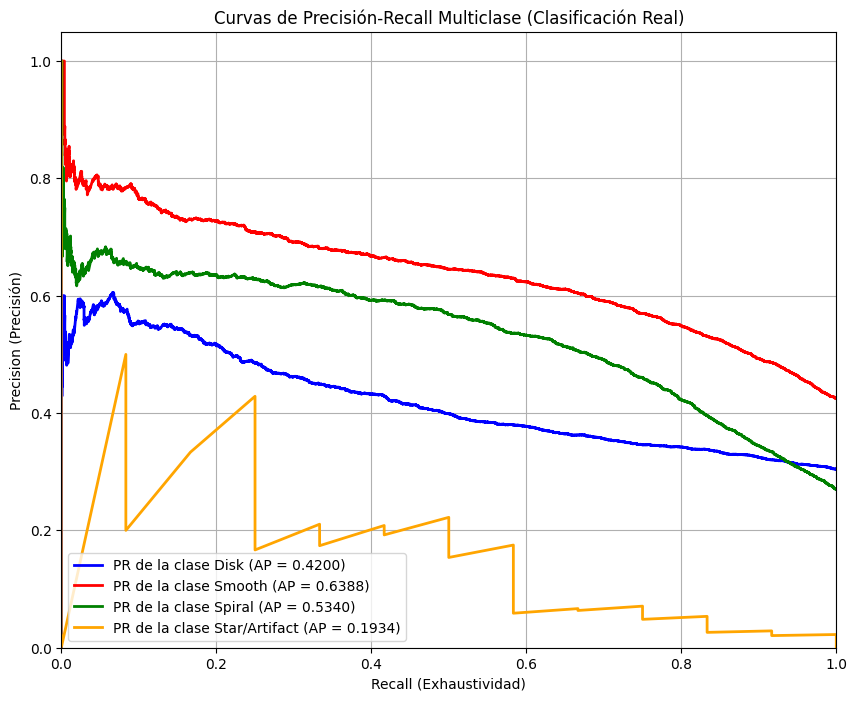

In [45]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ⚠️ Asumimos que las variables y_test, y_enc, class_names y el modelo clf están disponibles.

# --- 1. Preparación y Probabilidades ---

# Binarizar las etiquetas de prueba (y_test) para el formato Uno contra el Resto (OvR)
y_test_binarized = label_binarize(y_test, classes=np.unique(y_enc))
n_classes = y_test_binarized.shape[1]

# Obtener las probabilidades de predicción
y_score = clf.predict_proba(X_test)

# --- 2. Calcular Precision-Recall y AP para cada clase ---

precision = dict()
recall = dict()
average_precision = dict() # El Área bajo la Curva PR (AP)

for i in range(n_classes):
    # Calcula la precisión y el recall para la clase 'i'
    precision[i], recall[i], _ = precision_recall_curve(y_test_binarized[:, i], y_score[:, i])
    
    # Calcula el Average Precision (AP)
    average_precision[i] = average_precision_score(y_test_binarized[:, i], y_score[:, i])

# --- 3. Graficar las Curvas PR OvR ---

plt.figure(figsize=(10, 8))
# Colores para las 4 clases de galaxias
colors = ['blue', 'red', 'green', 'orange', 'purple'] 

for i, color in zip(range(n_classes), colors):
    if i < len(class_names):
        label_name = class_names[i]
    else:
        label_name = f'Clase {i}'

    plt.plot(recall[i], precision[i], color=color, lw=2,
             label=f'PR de la clase {label_name} (AP = {average_precision[i]:.4f})')

# Título y etiquetas
plt.xlabel('Recall (Exhaustividad)')
plt.ylabel('Precision (Precisión)')
plt.title('Curvas de Precisión-Recall Multiclase (Clasificación Real)')
plt.legend(loc="lower left")
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.show()

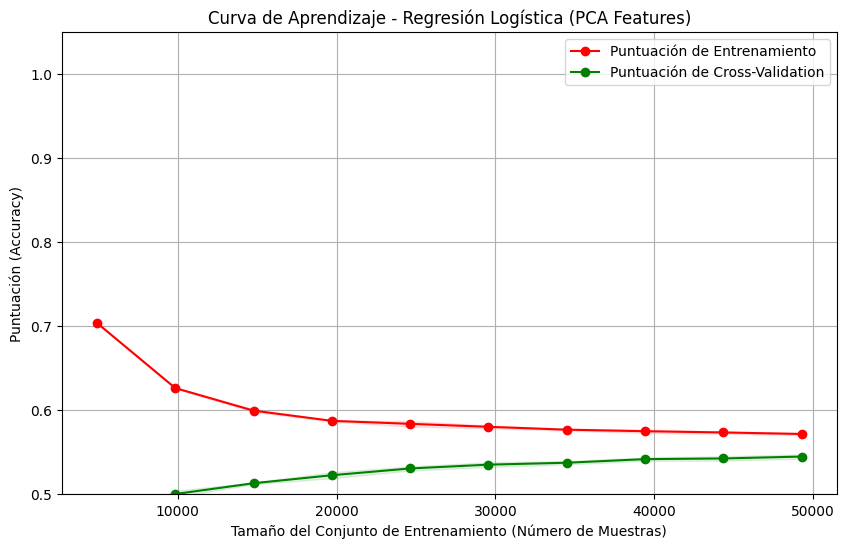

In [87]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# ⚠️ Asegúrate de que las variables X y y (totales, antes del split)
# sean las características PCA y las etiquetas codificadas y_enc.
# Asumimos que X=X_pca y y=y_enc del preprocesamiento total.
if 'X_pca' not in locals() or 'y_enc' not in locals():
    raise NameError("Las variables X_pca (features) y y_enc (etiquetas) no están disponibles. Asegúrate de ejecutar la celda de preprocesamiento de imágenes total primero.")

# Definir el modelo (debe ser el mismo que usaste para el entrenamiento final)
model = LogisticRegression(
    max_iter=3000,
    solver="saga",
    multi_class="multinomial",
    n_jobs=-1,
    random_state=42
)

# Generar los datos de la curva de aprendizaje
# Nota: Utilizamos X_pca y y_enc completos para que el test de validación sea robusto.
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X_pca, # Características de imagen (PCA)
    y=y_enc, # Etiquetas codificadas
    train_sizes=np.linspace(0.1, 1.0, 10), # Puntos de datos para evaluar
    cv=5, # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# --- Calcular promedios y desviaciones estándar ---
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# --- 2. Graficar la Curva de Aprendizaje ---

plt.figure(figsize=(10, 6))
plt.title("Curva de Aprendizaje - Regresión Logística (PCA Features)")
plt.xlabel("Tamaño del Conjunto de Entrenamiento (Número de Muestras)")
plt.ylabel("Puntuación (Accuracy)")
plt.grid(True)

# Puntuación de Entrenamiento (Training Score)
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Puntuación de Entrenamiento")

# Puntuación de Cross-Validation (Test Score)
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Puntuación de Cross-Validation")

# Rellenar el área de desviación estándar
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.legend(loc="best")
plt.ylim(0.5, 1.05) # Ajustar el límite y para visualizar el rendimiento esperado
plt.show()

In [46]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import time
import numpy as np

# ⚠️ Asegúrate de que X_train, y_train, X_test, y_test y class_names estén cargadas.
if 'X_train' not in locals():
    raise NameError("Las variables de entrenamiento (X_train, y_train, etc.) no están disponibles. Asegúrate de ejecutar el preprocesamiento de PCA primero.")

print("===> Entrenando modelo LinearSVC (SVM lineal) con PCA features...")

# Inicialización y Entrenamiento del Modelo SVM
# Dual=False y max_iter alto para conjuntos de datos grandes
svm_model = LinearSVC(
    multi_class='ovr', # Uno contra el Resto
    random_state=42,
    dual=False,        # Más rápido para n_samples > n_features
    max_iter=5000,     # Alto valor debido al volumen de datos
    C=1.0,             # Parámetro de regularización
    tol=1e-4           # Tolerancia
)

start_train_time = time.time()
svm_model.fit(X_train, y_train)
end_train_time = time.time()

print("Entrenamiento completado.")
print(f" Tiempo total de entrenamiento: {(end_train_time - start_train_time) / 60:.2f} minutos ({(end_train_time - start_train_time):.2f} segundos)")

# ------------------------------------------------------------------
# Evaluación del Rendimiento
# ------------------------------------------------------------------

# Predicciones
y_pred_svm = svm_model.predict(X_test)

print("\nReporte de Clasificación (SVM - PCA Features):")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

===> Entrenando modelo LinearSVC (SVM lineal) con PCA features...
Entrenamiento completado.
 Tiempo total de entrenamiento: 4.00 minutos (239.82 segundos)

Reporte de Clasificación (SVM - PCA Features):
               precision    recall  f1-score   support

         Disk       0.46      0.29      0.35      3744
       Smooth       0.58      0.74      0.65      5238
       Spiral       0.56      0.53      0.54      3322
Star/Artifact       0.06      0.08      0.07        12

     accuracy                           0.55     12316
    macro avg       0.41      0.41      0.40     12316
 weighted avg       0.53      0.55      0.53     12316



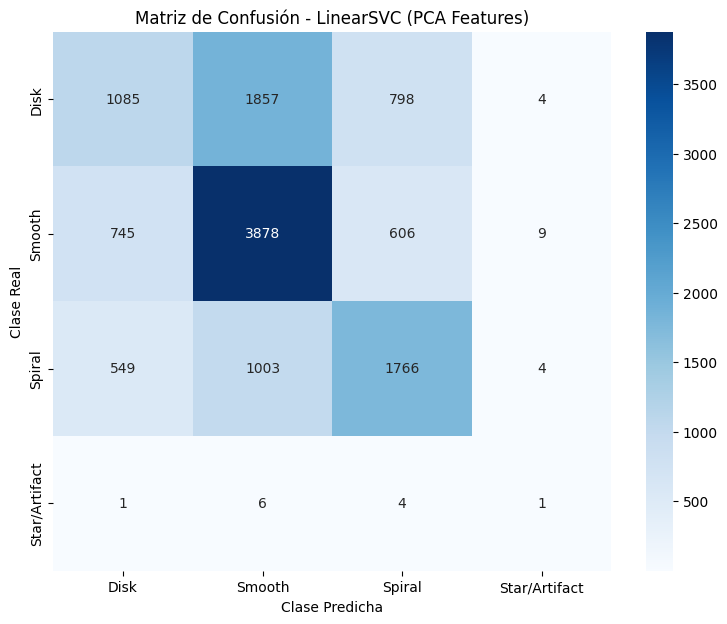

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ⚠️ Asumimos que y_test, y_pred_svm y class_names están cargadas.

# 1. Calcular la matriz de confusión
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# 2. Crear el gráfico
plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - LinearSVC (PCA Features)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

In [48]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# ⚠️ Asumimos que y_test, y_pred_svm, class_names y conf_matrix_svm están cargadas.

# -------------------------------------------------------------------------
# A. Cálculo de Métricas Detalladas (Specificity, NPV, G-Mean)
# -------------------------------------------------------------------------

report = classification_report(y_test, y_pred_svm, target_names=class_names, output_dict=True)
metrics_custom = {}
n_classes = len(class_names)

for i, class_name in enumerate(class_names):
    
    # Extracción de TP, FN, FP, TN (Estrategia OvR)
    TP = conf_matrix_svm[i, i]
    FN = conf_matrix_svm[i, :].sum() - TP
    FP = conf_matrix_svm[:, i].sum() - TP
    TN = conf_matrix_svm.sum() - (TP + FN + FP)
    
    # Cálculo
    sensitivity = TP / (TP + FN + 1e-10) # Igual a Recall
    specificity = TN / (TN + FP + 1e-10)
    npv = TN / (TN + FN + 1e-10)
    g_mean = np.sqrt(sensitivity * specificity)
    
    metrics_custom[class_name] = {
        'Specificity': specificity,
        'NPV': npv,
        'G-Mean': g_mean
    }

# -------------------------------------------------------------------------
# B. Consolidación de Tablas
# -------------------------------------------------------------------------

# Reporte Estándar (Precision, Recall, F1-Score)
df_standard = pd.DataFrame(report).transpose()
df_standard = df_standard.rename(columns={'recall': 'Sensitivity (Recall)'})

# Separar y unir DataFrames
df_avg = df_standard.loc[['accuracy', 'macro avg', 'weighted avg']].copy()
df_classes = df_standard.drop(['accuracy', 'macro avg', 'weighted avg']).copy()

df_custom = pd.DataFrame(metrics_custom).transpose()
df_final_classes = df_classes.join(df_custom)

# -------------------------------------------------------------------------
# C. Resultados Finales
# -------------------------------------------------------------------------

print("--- 1. Métricas por Clase (Clave + Detalladas) ---")
display(df_final_classes.style.format("{:.4f}"))

print("\n--- 2. Métricas Promedio y Exactitud General (Clave) ---")
# Eliminar el support de 'accuracy' para mejor visualización
df_avg = df_avg.drop(columns=['support'], errors='ignore') 
display(df_avg.style.format({
    'precision': '{:.4f}',
    'Sensitivity (Recall)': '{:.4f}',
    'f1-score': '{:.4f}',
    'accuracy': '{:.4f}'
}))

--- 1. Métricas por Clase (Clave + Detalladas) ---


,precision,Sensitivity (Recall),f1-score,support,Specificity,NPV,G-Mean
Disk,0.4559,0.2898,0.3543,3744.0000,0.8489,0.7324,0.4960
Smooth,0.5750,0.7404,0.6473,5238.0000,0.5951,0.7559,0.6638
Spiral,0.5564,0.5316,0.5437,3322.0000,0.8435,0.8298,0.6696
Star/Artifact,0.0556,0.0833,0.0667,12.0000,0.9986,0.9991,0.2885



--- 2. Métricas Promedio y Exactitud General (Clave) ---


,precision,Sensitivity (Recall),f1-score
accuracy,0.5464,0.5464,0.5464
macro avg,0.4107,0.4113,0.4030
weighted avg,0.5333,0.5464,0.5297


In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import time
import numpy as np

# ⚠️ Asumimos que X_train, y_train, X_test, y_test y class_names están cargadas (PCA features).

print("===> Entrenando Random Forest Classifier (Opción Rápida y Escalable)...")

# Inicialización del Modelo RF
# n_estimators alto y n_jobs=-1 para paralelización
rf_model = RandomForestClassifier(
    n_estimators=200,    # Número de árboles
    max_depth=15,        # Límite la profundidad para evitar sobreajuste extremo
    random_state=42,
    n_jobs=-1            # ¡Usa todos los núcleos disponibles!
)

start_train_time = time.time()
rf_model.fit(X_train, y_train)
end_train_time = time.time()

print("Entrenamiento Random Forest completado.")
print(f" Tiempo total de entrenamiento: {(end_train_time - start_train_time):.2f} segundos")

# Predicciones
y_pred_rf = rf_model.predict(X_test)

print("\nReporte de Clasificación (Random Forest - PCA Features):")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

===> Entrenando Random Forest Classifier (Opción Rápida y Escalable)...
Entrenamiento Random Forest completado.
 Tiempo total de entrenamiento: 26.24 segundos

Reporte de Clasificación (Random Forest - PCA Features):
               precision    recall  f1-score   support

         Disk       0.59      0.20      0.30      3744
       Smooth       0.50      0.93      0.65      5238
       Spiral       0.62      0.22      0.32      3322
Star/Artifact       0.00      0.00      0.00        12

     accuracy                           0.52     12316
    macro avg       0.43      0.34      0.32     12316
 weighted avg       0.56      0.52      0.46     12316



C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

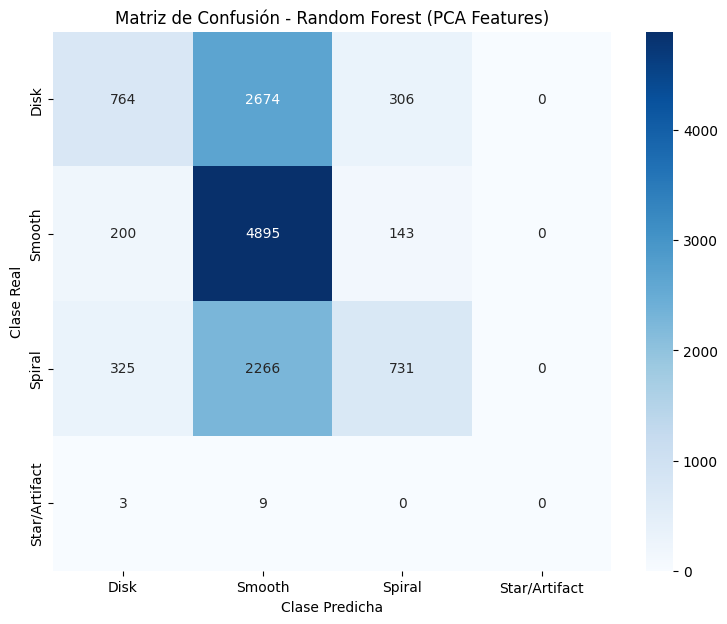


--- 1. Métricas por Clase (Random Forest) ---


,precision,Sensitivity (Recall),f1-score,support,Specificity,NPV,G-Mean
Disk,0.5913,0.2041,0.3034,3744.0000,0.9384,0.7297,0.4376
Smooth,0.4973,0.9345,0.6491,5238.0000,0.3008,0.8612,0.5302
Spiral,0.6195,0.2200,0.3247,3322.0000,0.9501,0.7673,0.4572
Star/Artifact,0.0000,0.0000,0.0000,12.0000,1.0000,0.9990,0.0000



--- 2. Métricas Promedio y Exactitud General ---


,precision,Sensitivity (Recall),f1-score
accuracy,0.5188,0.5188,0.5188
macro avg,0.4270,0.3397,0.3193
weighted avg,0.5583,0.5188,0.4559


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# --- Generación de Métricas ---
y_pred_rf = rf_model.predict(X_test)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf, target_names=class_names, output_dict=True)
metrics_custom = {}
n_classes = len(class_names)

for i, class_name in enumerate(class_names):
    TP = conf_matrix_rf[i, i]
    FN = conf_matrix_rf[i, :].sum() - TP
    FP = conf_matrix_rf[:, i].sum() - TP
    TN = conf_matrix_rf.sum() - (TP + FN + FP)
    
    sensitivity = TP / (TP + FN + 1e-10) # Recall
    specificity = TN / (TN + FP + 1e-10)
    npv = TN / (TN + FN + 1e-10)
    g_mean = np.sqrt(sensitivity * specificity)
    
    metrics_custom[class_name] = {
        'Specificity': specificity,
        'NPV': npv,
        'G-Mean': g_mean
    }

# Consolidación de Tablas
df_standard = pd.DataFrame(report).transpose().rename(columns={'recall': 'Sensitivity (Recall)'})
df_avg = df_standard.loc[['accuracy', 'macro avg', 'weighted avg']].copy()
df_classes = df_standard.drop(['accuracy', 'macro avg', 'weighted avg']).copy()
df_custom = pd.DataFrame(metrics_custom).transpose()
df_final_classes = df_classes.join(df_custom)

# -------------------------------------------------------------------------
# Resultados Finales
# -------------------------------------------------------------------------

# A. Visualizar la Matriz de Confusión
plt.figure(figsize=(9, 7))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Random Forest (PCA Features)')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

# B. Imprimir Métricas Detalladas por Clase
print("\n--- 1. Métricas por Clase (Random Forest) ---")
display(df_final_classes.style.format("{:.4f}"))

# C. Imprimir Métricas Promedio y Exactitud General
print("\n--- 2. Métricas Promedio y Exactitud General ---")
df_avg = df_avg.drop(columns=['support'], errors='ignore') 
display(df_avg.style.format({
    'precision': '{:.4f}',
    'Sensitivity (Recall)': '{:.4f}',
    'f1-score': '{:.4f}',
    'accuracy': '{:.4f}'
}))

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import time
import numpy as np

# ⚠️ Asumimos que X_train, y_train, X_test, y_test y class_names están cargadas.

print("===> Entrenando un único Árbol de Decisión (Decision Tree)...")

# Inicialización del Modelo Decision Tree
# max_depth se limita para evitar un sobreajuste extremo inmediato
dt_model = DecisionTreeClassifier(
    max_depth=10,         # Límite la profundidad para evitar sobreajuste extremo
    random_state=42
)

start_train_time = time.time()
dt_model.fit(X_train, y_train)
end_train_time = time.time()

print("Entrenamiento del Árbol de Decisión completado.")
print(f"⏱️ Tiempo total de entrenamiento: {(end_train_time - start_train_time):.4f} segundos")

# ------------------------------------------------------------------
# Evaluación del Rendimiento
# ------------------------------------------------------------------

# Predicciones
y_pred_dt = dt_model.predict(X_test)

print("\nReporte de Clasificación (Decision Tree - PCA Features):")
print(classification_report(y_test, y_pred_dt, target_names=class_names))

===> Entrenando un único Árbol de Decisión (Decision Tree)...


KeyboardInterrupt: 